# Statistical regularization Experiments
You have seen in the previous notebook that image reconstruction is an ill-defined problem.<br>
With regularization (i.e.: Solve <br>$\arg\min_x \lVert Ax-y \rVert^2 + \beta f\left(x\right) $ <br>, with $f (x)$ representing the "solution prior probability") you can achieve a denoised and unique solution in an easy way.  You can always see this as optimizing the *data fidelity term* plus the *regularization term* (or *prior probability* term)

The simplest $f(x)$ is the spatial gradient of the image: suppress strong variations from pixel to pixel: $\lVert \nabla x \rVert^2$ <br>
Its gradient (for the iterative reconstruction update) is: $\nabla^T \nabla x$. <br>
You can compute the spatial gradient using finite differences, like using `np.diff` and the `axis` parameter to differentiate along x or y

Do the following:
1. Try denoising on the deblurring problem, using a difficult condition(e.g.: $\sigma=2,\;\varepsilon=0.02$). Notice that there is no theoretical optimal value of $\beta$, try manually multiple values
2. Implement denoising for MR reconstruction in an undersampled case.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
i1 = np.load('testMR.npy')

# Task 1: Implement the *regularized* iterative for deblurring
The equations and the concepts are the same of the previous notebook. Now $\mathcal{L}=\lVert Ax-y \rVert^2 + \beta f\left(x\right)$<br>
The gradient descent iterative optimization algorithm works the same way, but the gradient becomes the sum of two terms:<br>
$g=A^Tr + +\beta \nabla f(x)=A^T r + \beta \nabla \cdot \nabla x$

So, the previous algorithm becomes: 
Set $x^0=0$; $y^0=0$. The "residual" $r=y-Ax$ is initialized as y. The iterative algorithm repeats the following:
1. The gradient is $g = A^T r + \beta \nabla \cdot \nabla x$ 
2. Compute the optimal step size: $\alpha= \frac{||g||^2}{||Ag||^2 + \beta \lVert \nabla g \rVert^2}$
3. Update $x$ with $x^{k+1}=x^k+\alpha g$
4. Update the residual $r^{k+1}=y-Ax^{k+1}$. Since $A$ is linear you can avoid to compute a second time $A$. Indeed $r^{k+1}=y-A^{k}+Ag^k = r^k + \alpha Ag$, so you can reuse $\alpha g$ from the previous step

Details:
* You can monitor your loss by just computing: $\left\lVert r \right \rVert^2 $, after every iteration. Remember that the vast majority of the time is spent computing $Ax$ or $A^T y$. Doing $\left\lVert r \right \rVert^2 $ is very cheap
* Write a function, or a class, that does the reconstruction. Parameters that the user need to set are: starting image (0 or a different initial guess), number of iterations, measured data. This function should return/provide: reconstructed image, loss value.
* In this problem $A$ if the convolution with a gaussian, and $A^T$ is the same operation. Write the previous function in a way that it's trivial to adapt it to all other cases (Radon transform for CT, FFT for MR)

In [3]:
sigma = 2.0
import scipy.ndimage as ndi

In [4]:
# Terms related to the Blurring
# Compute the fwd operation in the blurring case
def fwdOp (x__):
    return ndi.gaussian_filter(x__, sigma=sigma)
# Compute the adjoint operation in the blurring case
def bkwdOp (x__):
    return ndi.gaussian_filter(x__, sigma=sigma)


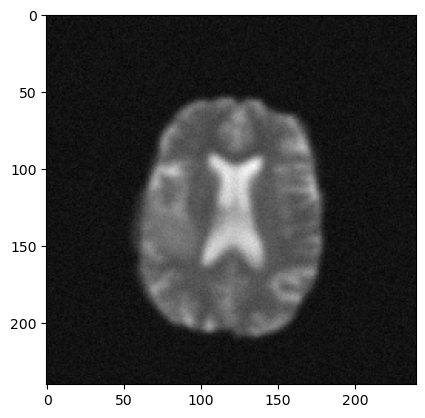

In [5]:
data = fwdOp(i1)+ np.random.normal(0, 0.02, i1.shape)
plt.imshow(data, cmap='gray')

In [6]:
# Terms related to the spatial regularization
def spatGrad (x__):
    x_grad = np.diff(x__, axis=0, append=0)
    y_grad = np.diff(x__, axis=1, append=0)
    return x_grad,y_grad
def spatAdj (x_grad__, y_grad__):
    x_adj = np.diff(x_grad__, axis=0, prepend=0)
    y_adj = np.diff(y_grad__, axis=1, prepend=0)
    return x_adj + y_adj

In [7]:
# Iterative reconstruction with gradient descent
def iterRecon (i1__,inImm__ = None, num_iters=100, beta_ =0.1):
    if inImm__ is not None:
        x = inImm__.copy()
    else:
        x = np.zeros_like(i1__)
    res = (fwdOp(x) - i1__)
    lossV = np.zeros((num_iters,2))
    for i in range(num_iters):
        # Compute the gradient of the data fidelity term
        grad_data = bkwdOp(res)
        # Compute the gradient of the regularization term
        x_grad, y_grad = spatGrad(x)
        grad_reg = spatAdj(x_grad, y_grad)
        # full grad
        grad = grad_data - beta_ * grad_reg
        # Compute the step size (using the exact equation)
        num = np.sum(grad**2)
        grad_fwd = fwdOp(grad)
        gx,gy = spatGrad(grad)
        den = np.sum(grad_fwd**2) + beta_ * np.sum(gx**2 + gy**2)
        alpha = num / den
        # update the image
        x = x - alpha * grad
        res = res - alpha * grad_fwd
        # Compute the loss
        lossV[i,0] = np.linalg.norm(res)**2
        lossV[i,1] = np.linalg.norm(grad_reg)**2
    return x,lossV

In [8]:
recImm,los= iterRecon(data, num_iters=100, beta_=0.01)

Text(0.5, 1.0, 'Original Data')

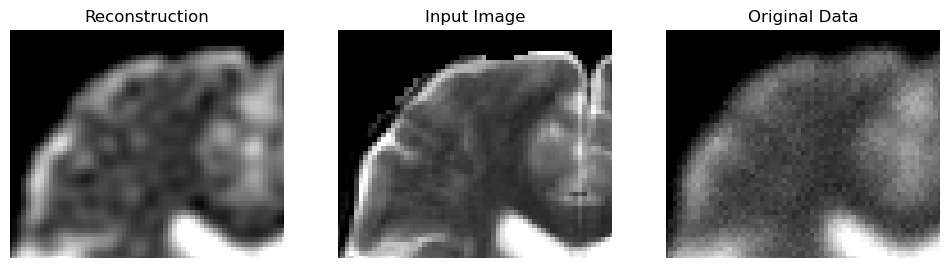

In [9]:
plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
plt.imshow(recImm, cmap='gray',vmin=0.1, vmax=.8)
plt.xlim(70,130)
plt.ylim(100,50)
plt.axis('off')
plt.title('Reconstruction')
plt.subplot(1,3,2)
plt.imshow(i1, cmap='gray',vmin=0.1, vmax=.8)
plt.xlim(70,130)
plt.ylim(100,50)
plt.axis('off')
plt.title('Input Image')
plt.subplot(1,3,3)
plt.imshow(data, cmap='gray',vmin=0.1, vmax=.8)
plt.xlim(70,130)
plt.ylim(100,50)
plt.axis('off')
plt.title('Original Data')  

In [10]:
betaList = [0.005,0.01,0.03,0.1,0.2,0.4,1]
recV = []
rmseV = []
lossV = []
dataFidV = []
for beta in betaList:
    recImm,los= iterRecon(data, num_iters=200, beta_=beta)
    recV.append(recImm)
    rmse = np.sqrt(np.mean((recImm - i1)**2))
    rmseV.append(rmse)
    lossV.append(los[-1,0]+beta*los[-1,1])
    dataFidV.append(los[-1,0])

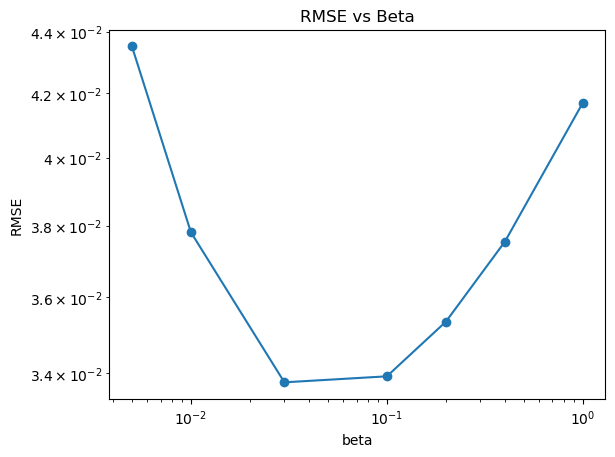

In [11]:
plt.plot(betaList, rmseV[:],'o-')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('beta')
plt.ylabel('RMSE')
_=plt.title('RMSE vs Beta')

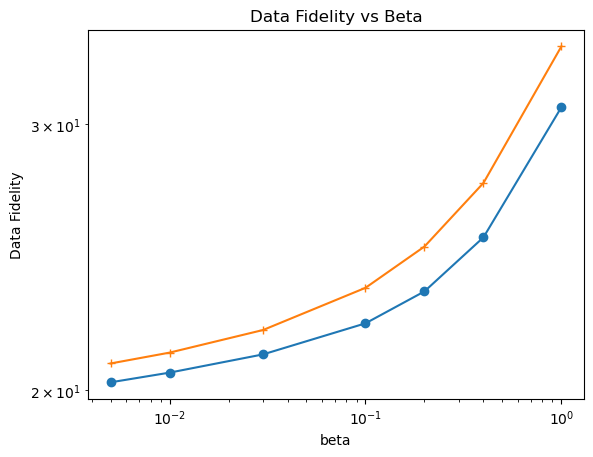

In [12]:
plt.plot(betaList, dataFidV[:],'o-')
plt.plot(betaList, lossV[:],'+-')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('beta')
plt.ylabel('Data Fidelity')
_=plt.title('Data Fidelity vs Beta')

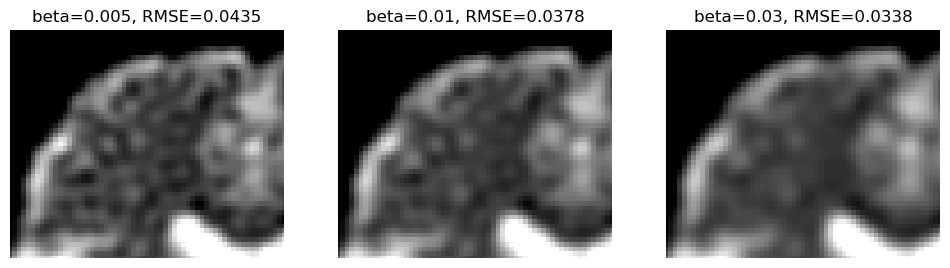

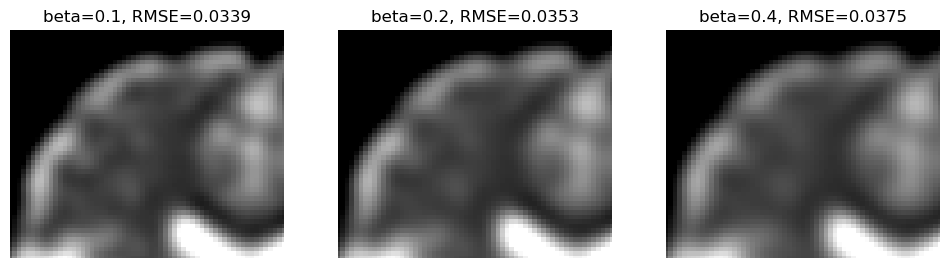

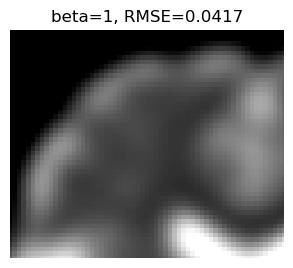

In [13]:

for i in range(len(betaList)):
    if i%3==0:
        plt.figure(figsize=(12,5))
    plt.subplot(1,3,(i%3)+1)
    plt.imshow(recV[i], cmap='gray',vmin=0.1, vmax=.8)
    plt.xlim(70,130)
    plt.ylim(100,50)
    plt.title(f'beta={betaList[i]}, RMSE={rmseV[i]:.4f}')
    plt.axis('off')
